In [26]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, precision_recall_curve

import tensorflow as tf
from tensorflow import keras

In [3]:
# Import dataset

df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Class counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Class %:
 Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

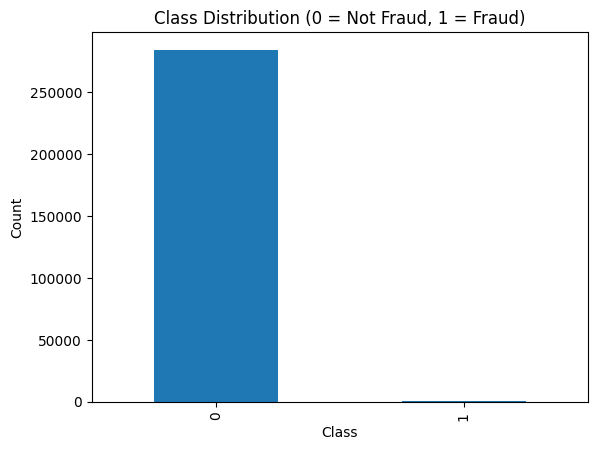

In [8]:
# EDA 

## Class imbalance

class_counts = df["Class"].value_counts()
print("\nClass counts:\n", class_counts)
print("\nClass %:\n", df["Class"].value_counts(normalize=True))

plt.figure()
class_counts.plot(kind="bar")
plt.title("Class Distribution (0 = Not Fraud, 1 = Fraud)")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show

In [ ]:
## Missing values

missing = df.isna().sum()

print("\n Missing values (top 10):\n", missing.sort_values(ascending = False).head(10))


 Missing values (top 10):
 Time      0
V16       0
Amount    0
V28       0
V27       0
V26       0
V25       0
V24       0
V23       0
V22       0
dtype: int64


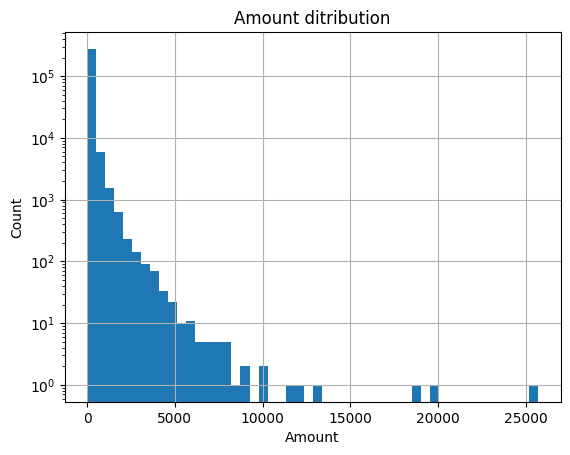

In [10]:
## Skew

plt.figure()
df["Amount"].hist(bins=50)
plt.title("Amount ditribution")
plt.xlabel("Amount")
plt.ylabel("Count")
plt.yscale("log")
plt.show()

In [13]:
# Target and features

y = df["Class"].astype(int).values
X = df.drop(columns = ["Class"]).copy()

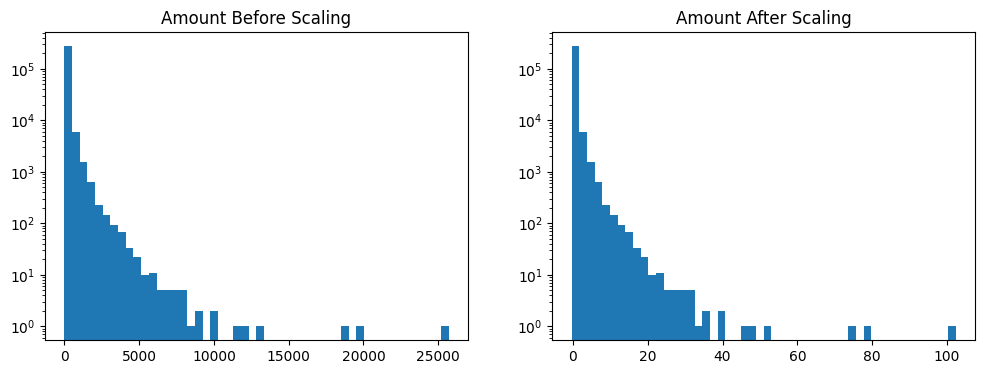

In [ ]:
# Scale time and Amount

scaler = StandardScaler()
X[["Time", "Amount"]] = scaler.fit_transform(X[["Time", "Amount"]])

# Visualization: scaling doesn't change shape, just units

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["Amount"], bins=50)
axes[0].set_title("Amount Before Scaling")
axes[0].set_yscale("log")

axes[1].hist(X["Amount"], bins=50)
axes[1].set_title("Amount After Scaling")
axes[1].set_yscale("log")
plt.show()

# Convert to numpy

X = X.values.astype(np.float32)

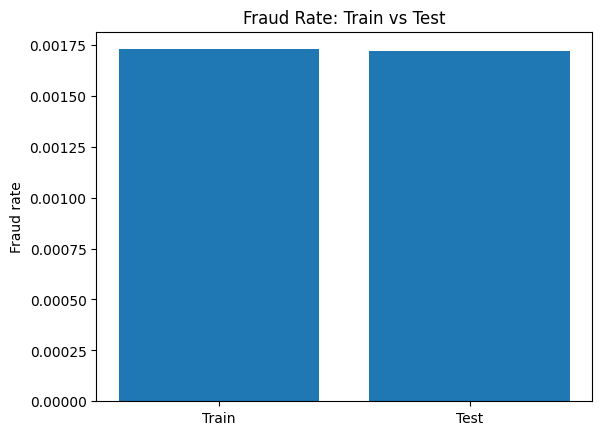

In [20]:
# Stratified train/test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Visualization: fraud rate stays similar

train_rate = y_train.mean()
test_rate = y_test.mean()
plt.figure()
plt.bar(["Train", "Test"], [train_rate, test_rate])
plt.title("Fraud Rate: Train vs Test")
plt.ylabel("Fraud rate")
plt.show()


Train fraud rate: 0.001729245759178389
Class weights: {0: 1.0, 1: np.float64(577.2868020304569)}


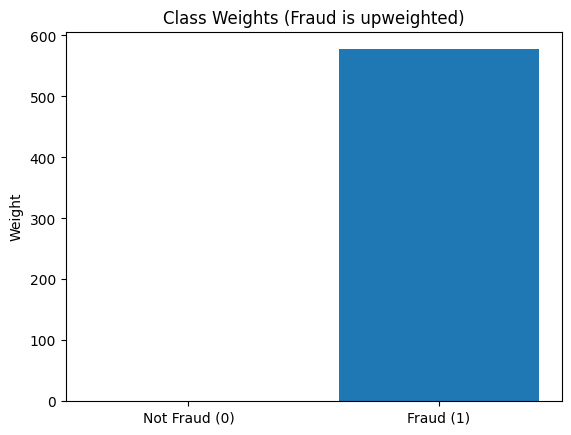

In [21]:
# Class weights for imbalance

neg, pos = np.bincount(y_train)
class_weight = {0: 1.0, 1: neg / max(pos, 1)}
print("\nTrain fraud rate:", pos / (neg + pos))
print("Class weights:", class_weight)

plt.figure()
plt.bar(["Not Fraud (0)", "Fraud (1)"], [class_weight[0], class_weight[1]])
plt.title("Class Weights (Fraud is upweighted)")
plt.ylabel("Weight")
plt.show()

In [22]:
# Build Neural Network

model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation="sigmoid"),
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Compile

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.AUC(curve="ROC", name="roc_auc"),
        keras.metrics.AUC(curve="PR", name="pr_auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=3,
        restore_best_weights=True
    )
]


Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9998 - pr_auc: 0.3653 - precision: 0.0089 - recall: 0.7910 - roc_auc: 0.8349 - val_loss: 0.2805 - val_pr_auc: 0.7255 - val_precision: 0.0892 - val_recall: 0.8554 - val_roc_auc: 0.9468
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4730 - pr_auc: 0.5791 - precision: 0.0396 - recall: 0.8907 - roc_auc: 0.9617 - val_loss: 0.1633 - val_pr_auc: 0.7222 - val_precision: 0.0910 - val_recall: 0.8795 - val_roc_auc: 0.9650
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4400 - pr_auc: 0.5030 - precision: 0.0416 - recall: 0.8810 - roc_auc: 0.9592 - val_loss: 0.1619 - val_pr_auc: 0.6152 - val_precision: 0.0539 - val_recall: 0.9036 - val_roc_auc: 0.9862
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3561 - pr_auc: 0.5028 - precision: 0.0449 - recall: 0.9035 - roc_auc: 0.9746 - val_loss: 0.1203 - val_pr_auc: 0.6442 - val_precision: 0.0702 - val_recall: 0.9036 - val_roc_auc: 0.9878


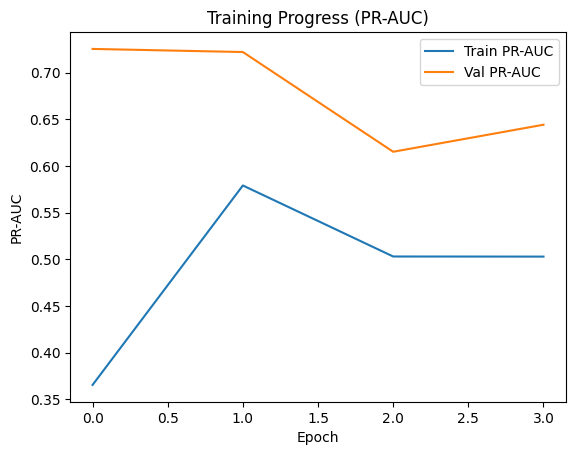

In [24]:
# Train

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=2048,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

# Visual: training progress (PR-AUC)
plt.figure()
plt.plot(history.history["pr_auc"], label="Train PR-AUC")
plt.plot(history.history["val_pr_auc"], label="Val PR-AUC")
plt.title("Training Progress (PR-AUC)")
plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.legend()
plt.show()


Test PR-AUC: 0.6625132281490085

=== Evaluation @ threshold = 0.5 ===
              precision    recall  f1-score   support

           0     0.9998    0.9827    0.9912     56864
           1     0.0812    0.8878    0.1488        98

    accuracy                         0.9825     56962
   macro avg     0.5405    0.9352    0.5700     56962
weighted avg     0.9982    0.9825    0.9897     56962

Confusion matrix:
 [[55880   984]
 [   11    87]]


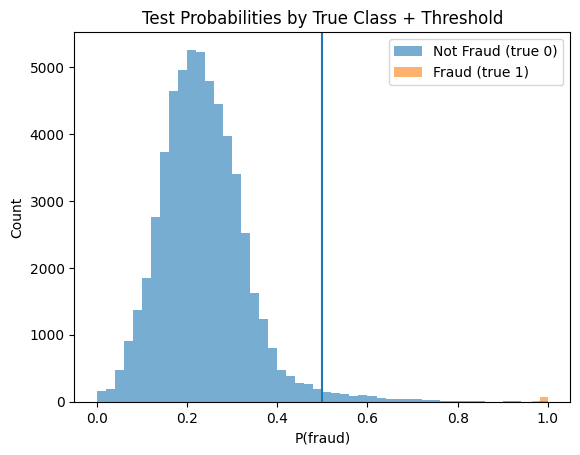

In [27]:
# Evaluate on NEVER-seen test set

y_prob = model.predict(X_test, verbose=0).ravel()

test_pr_auc = average_precision_score(y_test, y_prob)
print("\nTest PR-AUC:", test_pr_auc)


# Default threshold
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

print("\n=== Evaluation @ threshold = 0.5 ===")
print(classification_report(y_test, y_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

# Visual: probability separation + threshold line
plt.figure()
plt.hist(y_prob[y_test == 0], bins=50, alpha=0.6, label="Not Fraud (true 0)")
plt.hist(y_prob[y_test == 1], bins=50, alpha=0.6, label="Fraud (true 1)")
plt.axvline(threshold)
plt.title("Test Probabilities by True Class + Threshold")
plt.xlabel("P(fraud)")
plt.ylabel("Count")
plt.legend()
plt.show()

In [28]:
# Tune threshold

prec, rec, thr = precision_recall_curve(y_test, y_prob)

target_recall = 0.90
idxs = np.where(rec >= target_recall)[0]
if len(idxs) > 0:
    idx = idxs[-1]
    best_thr = thr[idx] if idx < len(thr) else 0.5
    print(f"\nThreshold for ~{int(target_recall*100)}% recall:", best_thr)

    y_pred_tuned = (y_prob >= best_thr).astype(int)
    print(f"\n=== Evaluation @ tuned threshold = {best_thr:.4f} ===")
    print(classification_report(y_test, y_pred_tuned, digits=4))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_tuned))
else:
    print("\nCould not find a threshold achieving target recall with this model.")


Threshold for ~90% recall: 0.39656168

=== Evaluation @ tuned threshold = 0.3966 ===
              precision    recall  f1-score   support

           0     0.9998    0.9529    0.9758     56864
           1     0.0322    0.9082    0.0622        98

    accuracy                         0.9529     56962
   macro avg     0.5160    0.9306    0.5190     56962
weighted avg     0.9982    0.9529    0.9743     56962

Confusion matrix:
 [[54188  2676]
 [    9    89]]


In [29]:
# Make predictions

results = pd.DataFrame({
    "prob_fraud": y_prob,
    "true_class": y_test
}).sort_values("prob_fraud", ascending=False)

print("\nTop 10 highest-risk transactions (test set):")
print(results.head(10))


Top 10 highest-risk transactions (test set):
       prob_fraud  true_class
2777          1.0           0
19638         1.0           1
50557         1.0           1
10623         1.0           1
46841         1.0           1
7299          1.0           1
9730          1.0           1
43032         1.0           1
9770          1.0           1
50203         1.0           0
